# HybridTransformerTEKTE / CTE-Net — reinferencia corregida

Esta versión infiere la arquitectura real de cada checkpoint y resuelve automáticamente el número de cabezas de atención comparando con las métricas guardadas.


HYBRID TRANSFORMER TEKTE / CTE-NET — REINFERENCIA COMPLETA
DATOS PROCESADOS
Device: cpu
X: (8213, 19, 512) float32
y: (8213,) int64
Sujetos: 120
Controles: 60
ADHD: 60
No utilizado: ['v36p']
Window size: 512
Stride: 256
CHECKPOINTS DESCUBIERTOS
Total: 50
Seed 0: /kaggle/input/datasets/alejandragomezr/models-cte-net/resultados_hybridtransformer_tekte_tdah_ARTICULO-20260715T225138Z-1-001/resultados_hybridtransformer_tekte_tdah_ARTICULO/repeat_seed_0/fixed_best_params_HybridTransformerTEKTE_TDAH/fixedparams_seed_0
Seed 1: /kaggle/input/datasets/alejandragomezr/models-cte-net/resultados_hybridtransformer_tekte_tdah_ARTICULO-20260715T225138Z-1-001/resultados_hybridtransformer_tekte_tdah_ARTICULO/repeat_seed_1/fixed_best_params_HybridTransformerTEKTE_TDAH/fixedparams_seed_1
Seed 2: /kaggle/input/datasets/alejandragomezr/models-cte-net/resultados_hybridtransformer_tekte_tdah_ARTICULO-20260715T225138Z-1-001/resultados_hybridtransformer_tekte_tdah_ARTICULO/repeat_seed_2/fixed_best_params_Hybrid

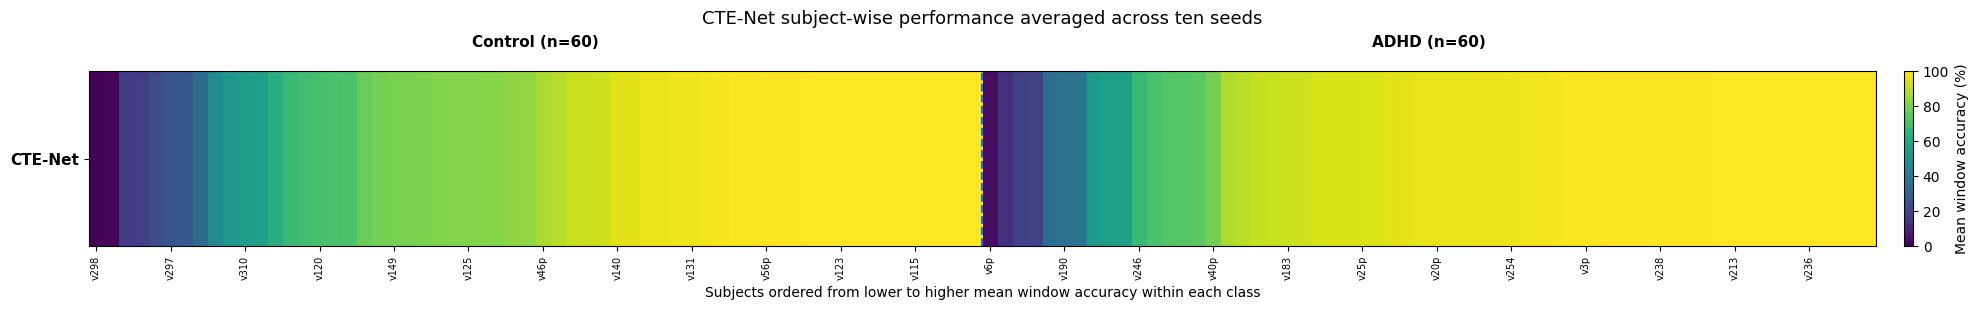


HEATMAP Y ARCHIVOS TIKZ
PNG: /kaggle/working/HybridTransformerTEKTE_reinference_complete/figures/CTE_Net_heatmap_mean_by_subject.png
PDF: /kaggle/working/HybridTransformerTEKTE_reinference_complete/figures/CTE_Net_heatmap_mean_by_subject.pdf
DAT: /kaggle/working/HybridTransformerTEKTE_reinference_complete/figures/tikz_data/CTE_Net_heatmap_mean_by_subject.dat
Ticks: /kaggle/working/HybridTransformerTEKTE_reinference_complete/figures/tikz_data/CTE_Net_heatmap_subject_ticks.dat
Clases: /kaggle/working/HybridTransformerTEKTE_reinference_complete/figures/tikz_data/CTE_Net_heatmap_classes.dat
Macros LaTeX: /kaggle/working/HybridTransformerTEKTE_reinference_complete/figures/tikz_data/CTE_Net_heatmap_axis_settings.tex
Orden CSV: /kaggle/working/HybridTransformerTEKTE_reinference_complete/figures/CTE_Net_heatmap_subject_order.csv

Proceso finalizado correctamente.


In [2]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import gc
import json
import pickle
import random
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    cohen_kappa_score,
    roc_auc_score,
)


# ============================================================
# 1. RUTAS Y CONFIGURACIÓN
# ============================================================

DATA_ROOT = Path(
    "/kaggle/input/datasets/daprosero/mi-tdah-dataset/"
    "MI_TDAH_Dataset/TDAH"
)

FOLDS_PATH = DATA_ROOT / "folds.pkl"
ADHD_DIR = DATA_ROOT / "ieee/ADHD_group"
CONTROL_DIR = DATA_ROOT / "ieee/Control_group"

MODEL_ROOT = Path(
    "/kaggle/input/datasets/alejandragomezr/models-cte-net/"
    "resultados_hybridtransformer_tekte_tdah_ARTICULO-20260715T225138Z-1-001/"
    "resultados_hybridtransformer_tekte_tdah_ARTICULO"
)

OUTPUT_ROOT = Path(
    "/kaggle/working/HybridTransformerTEKTE_reinference_complete"
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

FIGURE_DIR = OUTPUT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TIKZ_DIR = FIGURE_DIR / "tikz_data"
TIKZ_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BATCH_SIZE = 16
NUM_WORKERS = 0
N_SEEDS = 10
N_FOLDS = 5
METRIC_TOLERANCE = 1e-6
MODEL_NAME = "CTE-Net"
CHECKPOINT_MODEL_NAME = "HybridTransformerTEKTE"

# Hiperparámetros fijos del mejor trial del notebook original.
BEST_PARAMS = {
    "d_model": 32,
    "nhead": 2,
    "num_transformer_layers": 2,
    "dim_feedforward": 256,
    "transformer_dropout": 0.4,
    "phi_kernel_size": 99,
    "dx": 4,
    "dy": 2,
    "tau": 5,
    "mu": 5,
    "clf_hidden": 128,
    "clf_dropout": 0.1,
    "kernel_type": "rational_quadratic",
    "kernel_amplitude": 1.0,
    "kernel_length_scale": 1.0,
    "kernel_alpha": 1.0,
}


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


# ============================================================
# 3. CARGA Y SEGMENTACIÓN DE LOS 120 SUJETOS
# ============================================================

def clean_subject_id(value):
    if isinstance(value, bytes):
        value = value.decode("utf-8")

    value = Path(str(value)).name

    if value.lower().endswith(".mat"):
        value = value[:-4]

    return value.strip()


def normalize_folds(raw_folds):
    folds = []

    for fold_idx, fold_item in enumerate(raw_folds):
        if isinstance(fold_item, (list, tuple)) and len(fold_item) == 3:
            train_subjects, val_subjects, test_subjects = fold_item

        elif isinstance(fold_item, dict):
            train_subjects = (
                fold_item.get("train")
                or fold_item.get("train_subjects")
                or fold_item.get("subjects_train")
            )
            val_subjects = (
                fold_item.get("val")
                or fold_item.get("validation")
                or fold_item.get("val_subjects")
                or fold_item.get("subjects_val")
            )
            test_subjects = (
                fold_item.get("test")
                or fold_item.get("test_subjects")
                or fold_item.get("subjects_test")
            )

            if (
                train_subjects is None
                or val_subjects is None
                or test_subjects is None
            ):
                raise ValueError(
                    f"No fue posible interpretar el fold {fold_idx}."
                )
        else:
            raise TypeError(
                f"Formato no reconocido para el fold {fold_idx}: "
                f"{type(fold_item)}"
            )

        folds.append(
            (
                [clean_subject_id(x) for x in train_subjects],
                [clean_subject_id(x) for x in val_subjects],
                [clean_subject_id(x) for x in test_subjects],
            )
        )

    return folds


def build_mat_index(directory):
    directory = Path(directory)

    if not directory.exists():
        raise FileNotFoundError(
            f"No existe la carpeta de datos:\n{directory}"
        )

    files = {
        path.stem: path
        for path in sorted(directory.glob("*.mat"))
    }

    if not files:
        raise FileNotFoundError(
            f"No se encontraron archivos .mat en:\n{directory}"
        )

    return files


def load_subject_eeg(mat_path, subject_id, expected_channels=19):
    mat = scipy.io.loadmat(mat_path)

    if subject_id in mat:
        variable_name = subject_id
        raw = np.asarray(mat[subject_id])
    else:
        candidates = []

        for key, value in mat.items():
            if key.startswith("__"):
                continue

            array = np.asarray(value)

            if (
                array.ndim == 2
                and np.issubdtype(array.dtype, np.number)
                and expected_channels in array.shape
            ):
                candidates.append((key, array))

        if not candidates:
            available = {
                key: np.asarray(value).shape
                for key, value in mat.items()
                if not key.startswith("__")
            }
            raise ValueError(
                f"No se encontró una matriz EEG válida en {mat_path}.\n"
                f"Variables disponibles: {available}"
            )

        variable_name, raw = max(
            candidates,
            key=lambda item: item[1].size,
        )

    raw = np.asarray(raw, dtype=np.float32)

    # El notebook original aplicaba data[columna].T.
    eeg = raw.T

    if eeg.shape[0] != expected_channels and raw.shape[0] == expected_channels:
        eeg = raw

    if eeg.shape[0] != expected_channels:
        raise ValueError(
            f"{subject_id}: se esperaban {expected_channels} canales "
            f"y se obtuvo {eeg.shape}."
        )

    if not np.isfinite(eeg).all():
        raise ValueError(
            f"{subject_id}: la señal contiene NaN o Inf."
        )

    return eeg.astype(np.float32), variable_name


def process_adhd_subjects(window_size=512, overlap=0.50):
    with open(FOLDS_PATH, "rb") as file:
        raw_folds = pickle.load(file)

    folds = normalize_folds(raw_folds)

    if len(folds) != N_FOLDS:
        raise ValueError(
            f"Se esperaban {N_FOLDS} folds y se encontraron {len(folds)}."
        )

    protocol_subjects = set()
    test_counter = Counter()

    for fold_idx, (
        train_subjects,
        val_subjects,
        test_subjects,
    ) in enumerate(folds):
        train_set = set(train_subjects)
        val_set = set(val_subjects)
        test_set = set(test_subjects)

        if train_set & val_set:
            raise ValueError(
                f"Fold {fold_idx}: solapamiento train-validation."
            )
        if train_set & test_set:
            raise ValueError(
                f"Fold {fold_idx}: solapamiento train-test."
            )
        if val_set & test_set:
            raise ValueError(
                f"Fold {fold_idx}: solapamiento validation-test."
            )

        protocol_subjects.update(
            train_set | val_set | test_set
        )
        test_counter.update(test_subjects)

    if len(protocol_subjects) != 120:
        raise ValueError(
            f"Se esperaban 120 sujetos en folds.pkl y se encontraron "
            f"{len(protocol_subjects)}."
        )

    invalid_test_counts = {
        subject: count
        for subject, count in test_counter.items()
        if count != 1
    }

    if invalid_test_counts:
        raise ValueError(
            "Cada sujeto debe aparecer exactamente una vez en test: "
            f"{invalid_test_counts}"
        )

    adhd_files = build_mat_index(ADHD_DIR)
    control_files = build_mat_index(CONTROL_DIR)

    repeated = set(adhd_files) & set(control_files)

    if repeated:
        raise ValueError(
            f"Sujetos presentes en ambas clases: {sorted(repeated)}"
        )

    available_subjects = set(adhd_files) | set(control_files)
    missing_subjects = protocol_subjects - available_subjects

    if missing_subjects:
        raise FileNotFoundError(
            "Faltan archivos .mat para los sujetos:\n"
            f"{sorted(missing_subjects)}"
        )

    control_subjects = sorted(
        protocol_subjects & set(control_files)
    )
    adhd_subjects = sorted(
        protocol_subjects & set(adhd_files)
    )
    unused_subjects = sorted(
        available_subjects - protocol_subjects
    )

    if len(control_subjects) != 60 or len(adhd_subjects) != 60:
        raise ValueError(
            "La cohorte debe contener 60 controles y 60 sujetos ADHD. "
            f"Se obtuvo Control={len(control_subjects)}, "
            f"ADHD={len(adhd_subjects)}."
        )

    records = (
        [
            (subject, 0, "Control", control_files[subject])
            for subject in control_subjects
        ]
        +
        [
            (subject, 1, "ADHD", adhd_files[subject])
            for subject in adhd_subjects
        ]
    )

    stride = int(round(
        window_size * (1.0 - overlap)
    ))

    if stride <= 0:
        raise ValueError(
            "El stride calculado no es válido."
        )

    windows = []
    labels = []
    subject_ids = []
    window_ids = []
    metadata_rows = []
    global_window_index = 0

    for subject_position, (
        subject_id,
        label,
        class_name,
        mat_path,
    ) in enumerate(records):
        eeg, variable_name = load_subject_eeg(
            mat_path=mat_path,
            subject_id=subject_id,
            expected_channels=19,
        )

        n_samples = eeg.shape[1]

        if n_samples < window_size:
            raise ValueError(
                f"{subject_id}: solo tiene {n_samples} muestras."
            )

        local_window_id = 0

        for start_sample in range(
            0,
            n_samples - window_size + 1,
            stride,
        ):
            end_sample = start_sample + window_size

            windows.append(
                eeg[:, start_sample:end_sample]
            )
            labels.append(label)
            subject_ids.append(subject_id)
            window_ids.append(local_window_id)

            metadata_rows.append({
                "global_window_index": global_window_index,
                "subject_position": subject_position,
                "subject_id": subject_id,
                "label": label,
                "class_name": class_name,
                "window_id": local_window_id,
                "window_name": f"Window {local_window_id + 1}",
                "start_sample": start_sample,
                "end_sample": end_sample,
                "n_recording_samples": n_samples,
                "mat_variable": variable_name,
                "mat_filename": mat_path.name,
            })

            local_window_id += 1
            global_window_index += 1

    X = np.stack(windows).astype(np.float32)
    y_int = np.asarray(labels, dtype=np.int64)
    subject_ids = np.asarray(subject_ids, dtype=str)
    window_ids = np.asarray(window_ids, dtype=np.int64)
    metadata = pd.DataFrame(metadata_rows)

    if len(np.unique(subject_ids)) != 120:
        raise RuntimeError(
            "No se procesaron exactamente 120 sujetos."
        )

    print("=" * 80)
    print("DATOS PROCESADOS")
    print("=" * 80)
    print("Device:", DEVICE)
    print("X:", X.shape, X.dtype)
    print("y:", y_int.shape, y_int.dtype)
    print("Sujetos:", len(np.unique(subject_ids)))
    print("Controles:", len(control_subjects))
    print("ADHD:", len(adhd_subjects))
    print("No utilizado:", unused_subjects)
    print("Window size:", window_size)
    print("Stride:", stride)

    return {
        "X": X,
        "y_int": y_int,
        "subject_ids": subject_ids,
        "window_ids": window_ids,
        "metadata": metadata,
        "folds": folds,
        "unused_subjects": unused_subjects,
    }


# ============================================================
# 4. ARQUITECTURA ORIGINAL HYBRID TRANSFORMER + TEKTE
# ============================================================

class InspectableTransformerEncoder(nn.Module):
    def __init__(
        self,
        in_channels,
        d_model=None,
        num_heads=2,
        intermediate_dim=128,
        dropout=0.1,
        use_input_projection=True,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.d_model = d_model if d_model is not None else in_channels
        self.num_heads = num_heads
        self.intermediate_dim = intermediate_dim
        self.dropout_rate = dropout
        self.use_input_projection = use_input_projection

        if self.d_model % self.num_heads != 0:
            raise ValueError(
                f"d_model={self.d_model} debe ser divisible entre "
                f"num_heads={self.num_heads}"
            )

        if use_input_projection or self.d_model != in_channels:
            self.input_proj = nn.Linear(in_channels, self.d_model)
        else:
            self.input_proj = nn.Identity()

        self.self_attention = nn.MultiheadAttention(
            embed_dim=self.d_model,
            num_heads=self.num_heads,
            dropout=self.dropout_rate,
            batch_first=True,
        )

        self.self_attention_layer_norm = nn.LayerNorm(
            self.d_model,
            eps=1e-6,
        )
        self.self_attention_dropout = nn.Dropout(
            self.dropout_rate
        )

        self.feedforward_intermediate_dense = nn.Linear(
            self.d_model,
            self.intermediate_dim,
        )
        self.feedforward_output_dense = nn.Linear(
            self.intermediate_dim,
            self.d_model,
        )
        self.feedforward_dropout = nn.Dropout(
            self.dropout_rate
        )
        self.feedforward_layer_norm = nn.LayerNorm(
            self.d_model,
            eps=1e-6,
        )

        self._last_attention_scores = None

    def forward(
        self,
        inputs,
        training=False,
        need_weights=True,
        attn_mask=None,
    ):
        x = self.input_proj(inputs)

        attention_output, attention_scores = self.self_attention(
            query=x,
            key=x,
            value=x,
            attn_mask=attn_mask,
            need_weights=need_weights,
            average_attn_weights=False,
        )

        if need_weights:
            self._last_attention_scores = attention_scores
        else:
            self._last_attention_scores = None

        attention_output = self.self_attention_dropout(
            attention_output
        )
        attention_output = self.self_attention_layer_norm(
            x + attention_output
        )

        ff_output = self.feedforward_intermediate_dense(
            attention_output
        )
        ff_output = F.gelu(ff_output)
        ff_output = self.feedforward_output_dense(ff_output)
        ff_output = self.feedforward_dropout(ff_output)

        return self.feedforward_layer_norm(
            attention_output + ff_output
        )

    def get_attention_scores(self):
        if self._last_attention_scores is None:
            raise ValueError(
                "No se han calculado attention scores todavía."
            )
        return self._last_attention_scores


class ChannelwiseTemporalFilter(nn.Module):
    def __init__(self, channels, kernel_size=9):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(
                in_channels=channels,
                out_channels=channels,
                kernel_size=kernel_size,
                stride=1,
                padding=0,
                groups=channels,
                bias=True,
            ),
            nn.ReLU(),
            nn.AvgPool1d(
                kernel_size=4,
                stride=4,
            ),
            nn.BatchNorm1d(channels),
        )

    def forward(self, x):
        return self.net(x)


class TakensConv1D(nn.Module):
    def __init__(self, dx=5, dy=5, tau=1, mu=4):
        super().__init__()

        self.dx = int(dx)
        self.dy = int(dy)
        self.tau = int(tau)
        self.mu = int(mu)
        self.num_filters = self.dx + self.dy + 1

        kernel_size = self.mu + (self.dx - 1) * self.tau + 1
        self.kernel_size = kernel_size

        kernel = torch.zeros(
            self.num_filters,
            1,
            kernel_size,
        )

        for i in range(self.dx):
            kernel[
                i,
                0,
                self.mu + i * self.tau,
            ] = 1.0

        for i in range(self.dy):
            kernel[
                self.dx + i,
                0,
                (i + 1) * self.tau,
            ] = 1.0

        kernel[
            self.dx + self.dy,
            0,
            0,
        ] = 1.0

        kernel = torch.flip(
            kernel,
            dims=[-1],
        )

        self.register_buffer(
            "kernel",
            kernel,
        )

    def forward(self, inputs):
        batch_size, channels, time_length = inputs.shape

        reshaped = inputs.reshape(
            batch_size * channels,
            1,
            time_length,
        )

        conv_output = F.conv1d(
            reshaped,
            self.kernel,
            bias=None,
            stride=self.tau,
            padding=0,
        )

        length = conv_output.shape[-1]

        output = (
            conv_output
            .reshape(
                batch_size,
                channels,
                self.num_filters,
                length,
            )
            .permute(0, 1, 3, 2)
        )

        x_sub_t_minus_mu = output[..., :self.dx]
        y_sub_t_minus_1 = output[
            ...,
            self.dx:self.dx + self.dy,
        ]
        y_sub_t = output[..., -1:]

        return (
            x_sub_t_minus_mu,
            y_sub_t_minus_1,
            y_sub_t,
        )


class KernelLayer(nn.Module):
    def __init__(
        self,
        amplitude=1.0,
        trainable_amplitude=False,
        length_scale=1.0,
        trainable_length_scale=False,
        alpha=1.0,
        trainable_alpha=False,
        kernel_type="gaussian",
    ):
        super().__init__()

        self.kernel_type = kernel_type.lower()

        amp = torch.tensor(
            float(amplitude),
            dtype=torch.float32,
        )
        length = torch.tensor(
            float(length_scale),
            dtype=torch.float32,
        )
        alpha_tensor = torch.tensor(
            float(alpha),
            dtype=torch.float32,
        )

        if trainable_amplitude:
            self.amplitude = nn.Parameter(amp)
        else:
            self.register_buffer(
                "amplitude",
                amp,
            )

        if trainable_length_scale:
            self.length_scale = nn.Parameter(length)
        else:
            self.register_buffer(
                "length_scale",
                length,
            )

        if self.kernel_type == "rational_quadratic":
            if trainable_alpha:
                self.alpha = nn.Parameter(
                    alpha_tensor
                )
            else:
                self.register_buffer(
                    "alpha",
                    alpha_tensor,
                )

    def forward(self, X):
        difference = (
            X.unsqueeze(-2)
            - X.unsqueeze(-3)
        )
        distance_squared = (
            difference ** 2
        ).sum(dim=-1)

        amplitude = self.amplitude
        length_scale = torch.clamp(
            self.length_scale,
            min=1e-8,
        )

        if self.kernel_type == "gaussian":
            return (
                amplitude ** 2
            ) * torch.exp(
                -distance_squared
                / (
                    2.0
                    * length_scale ** 2
                )
            )

        if self.kernel_type == "rational_quadratic":
            alpha = torch.clamp(
                self.alpha,
                min=1e-8,
            )

            return (
                amplitude ** 2
            ) * (
                1.0
                + distance_squared
                / (
                    2.0
                    * alpha
                    * length_scale ** 2
                )
            ) ** (-alpha)

        raise ValueError(
            f"Unsupported kernel_type: {self.kernel_type}"
        )


class TransferEntropyLayer(nn.Module):
    def __init__(self, alpha=2):
        super().__init__()
        self.alpha = int(alpha)

    def compute_entropy(self, K_hadamard):
        trace_hadamard = torch.diagonal(
            K_hadamard,
            dim1=-2,
            dim2=-1,
        ).sum(dim=-1)

        trace_hadamard = (
            trace_hadamard
            .unsqueeze(-1)
            .unsqueeze(-1)
            + 1e-8
        )

        K_normalized = (
            K_hadamard / trace_hadamard
        )

        K_power = K_normalized @ K_normalized

        trace_power = torch.diagonal(
            K_power,
            dim1=-2,
            dim2=-1,
        ).sum(dim=-1)

        if self.alpha == 2:
            return -torch.log(
                trace_power + 1e-8
            )

        eigenvalues = torch.linalg.eigvalsh(
            K_normalized
        )
        eigenvalues = torch.clamp(
            eigenvalues.real,
            min=1e-8,
        )

        return torch.log(
            (eigenvalues ** self.alpha).sum(dim=-1)
            + 1e-8
        ) / (1 - self.alpha)

    def forward(
        self,
        K_x,
        K_y_minus_1,
        K_y,
    ):
        K_x_expanded = K_x.unsqueeze(2)
        K_y_minus_1_expanded = K_y_minus_1.unsqueeze(1)
        K_y_expanded = K_y.unsqueeze(1)

        H_1 = self.compute_entropy(
            K_y_minus_1_expanded
            * K_x_expanded
        )
        H_2 = self.compute_entropy(
            K_y_expanded
            * K_y_minus_1_expanded
            * K_x_expanded
        )
        H_3 = self.compute_entropy(
            K_y_expanded
            * K_y_minus_1_expanded
        )
        H_4 = self.compute_entropy(
            K_y_minus_1_expanded
        )

        return H_1 - H_2 + H_3 - H_4


class RemoveDiagonalFlatten(nn.Module):
    def forward(self, inputs):
        batch_size, channels, channels_2 = inputs.shape

        if channels != channels_2:
            raise ValueError(
                "La matriz de entrada no es cuadrada."
            )

        mask = ~torch.eye(
            channels,
            dtype=torch.bool,
            device=inputs.device,
        )

        return inputs[:, mask].reshape(
            batch_size,
            channels * (channels - 1),
        )


class HybridTransformerTEKTE(nn.Module):
    def __init__(
        self,
        chans=19,
        samples=512,
        d_model=64,
        nhead=2,
        num_transformer_layers=1,
        dim_feedforward=128,
        transformer_dropout=0.1,
        phi_kernel_size=9,
        dx=5,
        dy=5,
        tau=1,
        mu=4,
        kernel_type="rational_quadratic",
        kernel_amplitude=1.0,
        kernel_length_scale=1.0,
        kernel_alpha=1.0,
        trainable_kernel_amplitude=False,
        trainable_kernel_length_scale=False,
        trainable_kernel_alpha=False,
        clf_hidden=64,
        clf_dropout=0.3,
        use_pre_transformer_norm=True,
        use_post_transformer_norm=True,
    ):
        super().__init__()

        self.chans = chans
        self.samples = samples
        self.dx = dx
        self.dy = dy
        self.tau = tau
        self.mu = mu
        self.num_transformer_layers = num_transformer_layers
        self.d_model = d_model

        self.pre_transformer_norm = (
            nn.LayerNorm(chans)
            if use_pre_transformer_norm
            else nn.Identity()
        )

        self.transformer_layers = nn.ModuleList([
            InspectableTransformerEncoder(
                in_channels=(
                    chans if layer_index == 0
                    else d_model
                ),
                d_model=d_model,
                num_heads=nhead,
                intermediate_dim=dim_feedforward,
                dropout=transformer_dropout,
                use_input_projection=True,
            )
            for layer_index in range(
                num_transformer_layers
            )
        ])

        self.post_transformer_norm = (
            nn.LayerNorm(d_model)
            if use_post_transformer_norm
            else nn.Identity()
        )

        self.proj_back = nn.Linear(
            d_model,
            chans,
        )

        self.phi = ChannelwiseTemporalFilter(
            channels=chans,
            kernel_size=phi_kernel_size,
        )

        self.takens = TakensConv1D(
            dx=dx,
            dy=dy,
            tau=tau,
            mu=mu,
        )

        self.dense_proj_x = nn.Linear(
            dx,
            dx,
            bias=False,
        )
        self.dense_proj_y1 = nn.Linear(
            dy,
            dy,
            bias=False,
        )
        self.dense_proj_y = nn.Linear(
            1,
            1,
            bias=False,
        )

        self.kernel_x = KernelLayer(
            amplitude=kernel_amplitude,
            trainable_amplitude=trainable_kernel_amplitude,
            length_scale=kernel_length_scale,
            trainable_length_scale=trainable_kernel_length_scale,
            alpha=kernel_alpha,
            trainable_alpha=trainable_kernel_alpha,
            kernel_type=kernel_type,
        )

        self.kernel_y_minus_1 = KernelLayer(
            amplitude=kernel_amplitude,
            trainable_amplitude=trainable_kernel_amplitude,
            length_scale=kernel_length_scale,
            trainable_length_scale=trainable_kernel_length_scale,
            alpha=kernel_alpha,
            trainable_alpha=trainable_kernel_alpha,
            kernel_type=kernel_type,
        )

        self.kernel_y = KernelLayer(
            amplitude=kernel_amplitude,
            trainable_amplitude=trainable_kernel_amplitude,
            length_scale=kernel_length_scale,
            trainable_length_scale=trainable_kernel_length_scale,
            alpha=kernel_alpha,
            trainable_alpha=trainable_kernel_alpha,
            kernel_type=kernel_type,
        )

        self.transfer_entropy = TransferEntropyLayer(
            alpha=2
        )
        self.remove_diag_flatten = RemoveDiagonalFlatten()

        feature_dimension = chans * (chans - 1)

        self.classifier = nn.Sequential(
            nn.Linear(
                feature_dimension,
                clf_hidden,
            ),
            nn.ReLU(),
            nn.Dropout(clf_dropout),
            nn.Linear(
                clf_hidden,
                1,
            ),
        )

    def forward(
        self,
        x,
        return_dict=True,
        need_attention=False,
    ):
        batch_size, channels, samples = x.shape

        if channels != self.chans:
            raise ValueError(
                f"Se esperaban {self.chans} canales y llegaron {channels}."
            )

        if samples != self.samples:
            raise ValueError(
                f"Se esperaban {self.samples} muestras y llegaron {samples}."
            )

        x_transposed = x.transpose(1, 2)
        x_transposed = self.pre_transformer_norm(
            x_transposed
        )

        hidden = x_transposed
        attention_scores_all = (
            [] if need_attention else None
        )

        for layer in self.transformer_layers:
            hidden = layer(
                hidden,
                need_weights=need_attention,
            )

            if need_attention:
                attention_scores_all.append(
                    layer.get_attention_scores()
                )

        hidden = self.post_transformer_norm(
            hidden
        )

        Xf = self.proj_back(hidden)
        Xf = Xf.transpose(1, 2)

        phi = self.phi(Xf)

        x_sub, y_minus_1, y_t = self.takens(
            phi
        )

        x_sub = self.dense_proj_x(x_sub)
        y_minus_1 = self.dense_proj_y1(
            y_minus_1
        )
        y_t = self.dense_proj_y(y_t)

        K_x = self.kernel_x(x_sub)
        K_y_minus_1 = self.kernel_y_minus_1(
            y_minus_1
        )
        K_y = self.kernel_y(y_t)

        transfer_entropy = self.transfer_entropy(
            K_x,
            K_y_minus_1,
            K_y,
        )

        features = self.remove_diag_flatten(
            transfer_entropy
        )

        logits = self.classifier(
            features
        ).squeeze(-1)

        probabilities = torch.sigmoid(logits)

        if return_dict:
            return {
                "logits": logits,
                "probs": probabilities,
                "T": transfer_entropy,
                "features": features,
                "Xf": Xf,
                "phi": phi,
                "attention_scores": (
                    attention_scores_all
                    if need_attention
                    else None
                ),
            }

        return logits


def build_model_from_architecture(architecture, nhead):
    """Reconstruye exactamente la arquitectura inferida del checkpoint."""
    return HybridTransformerTEKTE(
        chans=architecture["chans"],
        samples=architecture["samples"],
        d_model=architecture["d_model"],
        nhead=int(nhead),
        num_transformer_layers=architecture["num_transformer_layers"],
        dim_feedforward=architecture["dim_feedforward"],
        # Dropout no altera la inferencia porque model.eval() lo desactiva.
        transformer_dropout=0.0,
        phi_kernel_size=architecture["phi_kernel_size"],
        dx=architecture["dx"],
        dy=architecture["dy"],
        tau=architecture["tau"],
        mu=architecture["mu"],
        kernel_type=architecture["kernel_type"],
        kernel_amplitude=architecture["kernel_amplitude"],
        kernel_length_scale=architecture["kernel_length_scale"],
        kernel_alpha=architecture["kernel_alpha"],
        trainable_kernel_amplitude=False,
        trainable_kernel_length_scale=False,
        trainable_kernel_alpha=False,
        clf_hidden=architecture["clf_hidden"],
        clf_dropout=0.0,
        use_pre_transformer_norm=architecture["use_pre_transformer_norm"],
        use_post_transformer_norm=architecture["use_post_transformer_norm"],
    )


# ============================================================
# 5. DESCUBRIMIENTO Y CARGA DE CHECKPOINTS
# ============================================================

def safe_torch_load(path):
    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=True,
        )
    except TypeError:
        return torch.load(
            path,
            map_location="cpu",
        )
    except Exception:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )


def load_state_dict_file(path):
    loaded = safe_torch_load(path)

    if not isinstance(loaded, dict):
        raise TypeError(
            f"El checkpoint no contiene un diccionario: {path}"
        )

    if "model_state_dict" in loaded:
        state_dict = loaded["model_state_dict"]
    elif "state_dict" in loaded:
        state_dict = loaded["state_dict"]
    else:
        state_dict = loaded

    cleaned = {}

    for key, value in state_dict.items():
        clean_key = key

        for prefix in (
            "module.",
            "_orig_mod.",
        ):
            if clean_key.startswith(prefix):
                clean_key = clean_key[len(prefix):]

        cleaned[clean_key] = value

    return cleaned



def _tensor_scalar(state_dict, key, default):
    value = state_dict.get(key, None)
    if value is None:
        return float(default)
    if torch.is_tensor(value):
        return float(value.detach().cpu().reshape(-1)[0].item())
    return float(value)


def infer_architecture_from_state_dict(state_dict):
    """
    Infiere los hiperparámetros estructurales directamente desde los pesos.

    Esto evita asumir los parámetros del manuscrito cuando los checkpoints
    corresponden a otra ejecución de Optuna.
    """
    required_keys = [
        "proj_back.weight",
        "transformer_layers.0.feedforward_intermediate_dense.weight",
        "phi.net.0.weight",
        "takens.kernel",
        "dense_proj_x.weight",
        "dense_proj_y1.weight",
        "classifier.0.weight",
    ]

    missing = [key for key in required_keys if key not in state_dict]
    if missing:
        raise KeyError(
            "No es posible inferir la arquitectura. Faltan claves: "
            f"{missing}"
        )

    # Transformer
    layer_indices = []
    pattern = re.compile(r"^transformer_layers\.(\d+)\.")
    for key in state_dict:
        match = pattern.match(key)
        if match:
            layer_indices.append(int(match.group(1)))

    num_layers = max(layer_indices) + 1 if layer_indices else 0
    if num_layers <= 0:
        raise ValueError("No se detectaron capas Transformer.")

    proj_back_weight = state_dict["proj_back.weight"]
    chans = int(proj_back_weight.shape[0])
    d_model = int(proj_back_weight.shape[1])

    ff_weight = state_dict[
        "transformer_layers.0.feedforward_intermediate_dense.weight"
    ]
    dim_feedforward = int(ff_weight.shape[0])

    # Filtro temporal y clasificador
    phi_kernel_size = int(state_dict["phi.net.0.weight"].shape[-1])
    clf_hidden = int(state_dict["classifier.0.weight"].shape[0])

    # Dimensiones de Takens
    dx = int(state_dict["dense_proj_x.weight"].shape[0])
    dy = int(state_dict["dense_proj_y1.weight"].shape[0])

    takens_kernel = state_dict["takens.kernel"].detach().cpu()
    expected_filters = dx + dy + 1
    if int(takens_kernel.shape[0]) != expected_filters:
        raise ValueError(
            "El número de filtros Takens no coincide con dx+dy+1: "
            f"{tuple(takens_kernel.shape)} vs {expected_filters}."
        )

    # El constructor original hace torch.flip(kernel, dims=[-1]).
    original_kernel = torch.flip(takens_kernel, dims=[-1])

    positions = []
    for filter_idx in range(expected_filters):
        nonzero = torch.nonzero(
            original_kernel[filter_idx, 0].abs() > 0.5,
            as_tuple=False,
        ).reshape(-1)
        if len(nonzero) != 1:
            raise ValueError(
                f"Filtro Takens {filter_idx}: se esperaba un único 1, "
                f"pero se encontraron posiciones {nonzero.tolist()}."
            )
        positions.append(int(nonzero.item()))

    x_positions = positions[:dx]
    y_positions = positions[dx:dx + dy]
    present_position = positions[-1]

    if present_position != 0:
        raise ValueError(
            f"La posición presente de Takens debería ser 0 y es {present_position}."
        )

    mu = int(x_positions[0])

    tau_candidates = []
    if dx > 1:
        tau_candidates.extend(
            x_positions[i + 1] - x_positions[i]
            for i in range(dx - 1)
        )
    if dy >= 1:
        tau_candidates.append(y_positions[0])
    if dy > 1:
        tau_candidates.extend(
            y_positions[i + 1] - y_positions[i]
            for i in range(dy - 1)
        )

    tau_candidates = [int(x) for x in tau_candidates if int(x) > 0]
    if not tau_candidates:
        raise ValueError("No fue posible inferir tau del kernel Takens.")

    if len(set(tau_candidates)) != 1:
        raise ValueError(
            f"Valores de tau inconsistentes en Takens: {tau_candidates}."
        )

    tau = int(tau_candidates[0])

    expected_kernel_size = mu + (dx - 1) * tau + 1
    actual_kernel_size = int(takens_kernel.shape[-1])
    if expected_kernel_size != actual_kernel_size:
        raise ValueError(
            "El kernel Takens inferido no es consistente: "
            f"esperado={expected_kernel_size}, real={actual_kernel_size}."
        )

    # Tipo y parámetros del kernel de información.
    kernel_type = (
        "rational_quadratic"
        if "kernel_x.alpha" in state_dict
        else "gaussian"
    )

    architecture = {
        "chans": chans,
        "samples": 512,
        "d_model": d_model,
        "num_transformer_layers": int(num_layers),
        "dim_feedforward": dim_feedforward,
        "phi_kernel_size": phi_kernel_size,
        "dx": dx,
        "dy": dy,
        "tau": tau,
        "mu": mu,
        "kernel_type": kernel_type,
        "kernel_amplitude": _tensor_scalar(
            state_dict, "kernel_x.amplitude", 1.0
        ),
        "kernel_length_scale": _tensor_scalar(
            state_dict, "kernel_x.length_scale", 1.0
        ),
        "kernel_alpha": _tensor_scalar(
            state_dict, "kernel_x.alpha", 1.0
        ),
        "clf_hidden": clf_hidden,
        "use_pre_transformer_norm": (
            "pre_transformer_norm.weight" in state_dict
        ),
        "use_post_transformer_norm": (
            "post_transformer_norm.weight" in state_dict
        ),
    }

    return architecture


def architecture_signature(architecture):
    keys = [
        "chans",
        "samples",
        "d_model",
        "num_transformer_layers",
        "dim_feedforward",
        "phi_kernel_size",
        "dx",
        "dy",
        "tau",
        "mu",
        "kernel_type",
        "clf_hidden",
        "use_pre_transformer_norm",
        "use_post_transformer_norm",
    ]
    return tuple((key, architecture[key]) for key in keys)


def extract_seed_from_path(path):
    path_string = str(path)

    patterns = [
        r"repeat_seed_(\d+)",
        r"fixedparams[^/\\]*seed_(\d+)",
        r"fixed_seed_(\d+)",
        r"seed[_-](\d+)",
    ]

    for pattern in patterns:
        match = re.search(
            pattern,
            path_string,
            flags=re.IGNORECASE,
        )

        if match:
            return int(match.group(1))

    return None


def extract_fold_from_path(path):
    matches = re.findall(
        r"fold_(\d+)",
        str(path),
        flags=re.IGNORECASE,
    )

    if not matches:
        return None

    return int(matches[-1])


def checkpoint_priority(path):
    filename = path.name.lower()

    if filename == "best_state.pt":
        return 100
    if filename == "final_state_dict.pt":
        return 80
    if filename.endswith("state_dict.pt"):
        return 70
    if filename == "resume_checkpoint.pt":
        return 20

    return 0


def discover_checkpoints(model_root):
    if not model_root.exists():
        raise FileNotFoundError(
            f"No existe la carpeta de modelos:\n{model_root}"
        )

    all_candidates = []

    for pattern in (
        "best_state.pt",
        "final_state_dict.pt",
        "*state_dict.pt",
        "resume_checkpoint.pt",
    ):
        all_candidates.extend(
            model_root.rglob(pattern)
        )

    # Quitar duplicados producidos por patrones solapados.
    all_candidates = sorted(
        set(all_candidates),
        key=str,
    )

    grouped = {}

    for checkpoint_path in all_candidates:
        seed = extract_seed_from_path(
            checkpoint_path
        )
        fold = extract_fold_from_path(
            checkpoint_path
        )

        if seed is None or fold is None:
            continue

        if not (0 <= seed < N_SEEDS):
            continue

        if not (0 <= fold < N_FOLDS):
            continue

        grouped.setdefault(
            (seed, fold),
            [],
        ).append(checkpoint_path)

    mapping = {
        key: max(
            paths,
            key=checkpoint_priority,
        )
        for key, paths in grouped.items()
    }

    expected = {
        (seed, fold)
        for seed in range(N_SEEDS)
        for fold in range(N_FOLDS)
    }

    missing = sorted(
        expected - set(mapping)
    )

    if missing:
        raise FileNotFoundError(
            "No se encontraron los 50 checkpoints esperados.\n"
            f"Combinaciones faltantes: {missing}\n\n"
            "Archivos de pesos descubiertos:\n"
            + "\n".join(
                str(path)
                for path in all_candidates
            )
        )

    print("=" * 80)
    print("CHECKPOINTS DESCUBIERTOS")
    print("=" * 80)
    print("Total:", len(mapping))

    for seed in range(N_SEEDS):
        print(
            f"Seed {seed}: "
            f"{mapping[(seed, 0)].parent.parent}"
        )

    return mapping


def load_saved_fold_result(checkpoint_path):
    fold_directory = checkpoint_path.parent
    result_path = fold_directory / "fold_result.pkl"

    if not result_path.exists():
        # Buscar el resultado dentro del mismo fold por si el peso
        # se encuentra en una subcarpeta adicional.
        matches = list(
            fold_directory.rglob(
                "fold_result.pkl"
            )
        )

        if len(matches) == 1:
            result_path = matches[0]
        else:
            raise FileNotFoundError(
                f"No se encontró fold_result.pkl asociado a:\n"
                f"{checkpoint_path}"
            )

    with open(result_path, "rb") as file:
        result = pickle.load(file)

    if (
        "fold_metrics" not in result
        or result["fold_metrics"] is None
    ):
        raise KeyError(
            f"{result_path} no contiene fold_metrics válidas."
        )

    return result, result_path


# ============================================================
# 6. INFERENCIA Y MÉTRICAS
# ============================================================

def get_test_partition(data, fold_idx):
    test_subjects = data["folds"][fold_idx][2]

    mask = np.isin(
        data["subject_ids"],
        np.asarray(
            test_subjects,
            dtype=str,
        ),
    )

    test_data = {
        "X": data["X"][mask],
        "y": data["y_int"][mask],
        "subject_ids": data["subject_ids"][mask],
        "window_ids": data["window_ids"][mask],
        "metadata": (
            data["metadata"]
            .loc[mask]
            .reset_index(drop=True)
            .copy()
        ),
        "test_subjects": test_subjects,
    }

    n_test_subjects = len(
        np.unique(
            test_data["subject_ids"]
        )
    )

    if n_test_subjects != 24:
        raise ValueError(
            f"Fold {fold_idx}: se esperaban 24 sujetos "
            f"y se encontraron {n_test_subjects}."
        )

    return test_data


def infer_hybrid_transformer(
    model,
    X,
    batch_size=BATCH_SIZE,
):
    dataset = TensorDataset(
        torch.from_numpy(
            np.asarray(
                X,
                dtype=np.float32,
            )
        )
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    probability_batches = []

    model.eval()

    with torch.inference_mode():
        for (batch_x,) in loader:
            batch_x = batch_x.to(
                device=DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )

            output = model(
                batch_x,
                return_dict=True,
                need_attention=False,
            )

            probabilities = output["probs"]

            probability_batches.append(
                probabilities
                .detach()
                .cpu()
                .numpy()
            )

    probability_adhd = np.concatenate(
        probability_batches,
        axis=0,
    ).astype(np.float32)

    predictions = (
        probability_adhd >= 0.5
    ).astype(np.int64)

    return probability_adhd, predictions


def calculate_metrics(y_true, y_pred, y_prob):
    y_true = np.asarray(
        y_true,
        dtype=np.int64,
    )
    y_pred = np.asarray(
        y_pred,
        dtype=np.int64,
    )
    y_prob = np.asarray(
        y_prob,
        dtype=np.float64,
    )

    try:
        auc_value = roc_auc_score(
            y_true,
            y_prob,
        )
    except ValueError:
        auc_value = np.nan

    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                y_pred,
                average="binary",
                zero_division=0,
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                y_pred,
                average="binary",
                zero_division=0,
            )
        ),
        "kappa": float(
            cohen_kappa_score(
                y_true,
                y_pred,
            )
        ),
        "auc": float(auc_value),
    }


def summarize_values(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    return {
        "mean": float(
            np.nanmean(values)
        ),
        "std_population": float(
            np.nanstd(
                values,
                ddof=0,
            )
        ),
        "std_sample": float(
            np.nanstd(
                values,
                ddof=1,
            )
        ) if len(values) > 1 else 0.0,
        "n": int(len(values)),
    }




def resolve_nhead_for_architecture(
    architecture,
    state_dict,
    test,
    saved_metrics,
):
    """
    El número de cabezas no queda codificado en las dimensiones del
    state_dict. Se prueba el espacio original {1, 2} y se selecciona la
    configuración que reproduce mejor las métricas guardadas.
    """
    candidate_heads = [
        head
        for head in (1, 2)
        if architecture["d_model"] % head == 0
    ]

    if not candidate_heads:
        raise ValueError(
            f"No hay un nhead válido para d_model={architecture['d_model']}."
        )

    comparable_metrics = [
        metric
        for metric in ("accuracy", "recall", "precision", "kappa", "auc")
        if metric in saved_metrics
    ]

    candidate_results = []

    for nhead in candidate_heads:
        model = build_model_from_architecture(
            architecture,
            nhead=nhead,
        ).to(DEVICE)

        model.load_state_dict(state_dict, strict=True)

        probabilities, predictions = infer_hybrid_transformer(
            model=model,
            X=test["X"],
            batch_size=BATCH_SIZE,
        )

        metrics = calculate_metrics(
            y_true=test["y"],
            y_pred=predictions,
            y_prob=probabilities,
        )

        differences = {
            metric: abs(
                float(metrics[metric]) - float(saved_metrics[metric])
            )
            for metric in comparable_metrics
        }
        score = float(sum(differences.values()))
        exact = bool(
            all(
                np.isclose(
                    metrics[metric],
                    float(saved_metrics[metric]),
                    atol=METRIC_TOLERANCE,
                    rtol=0.0,
                    equal_nan=True,
                )
                for metric in comparable_metrics
            )
        )

        candidate_results.append({
            "nhead": int(nhead),
            "score": score,
            "exact": exact,
            "metrics": metrics,
        })

        print(
            f"  prueba nhead={nhead}: "
            f"accuracy={metrics['accuracy']:.10f}, "
            f"diferencia_total={score:.12g}, exacto={exact}"
        )

        del model, probabilities, predictions
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    candidate_results.sort(
        key=lambda item: (
            not item["exact"],
            item["score"],
            # En empate, priorizar 2 porque fue la configuración usual.
            0 if item["nhead"] == 2 else 1,
        )
    )

    selected = candidate_results[0]

    print(
        f"  nhead seleccionado: {selected['nhead']} "
        f"(exacto={selected['exact']}, score={selected['score']:.12g})"
    )

    return int(selected["nhead"])


# ============================================================
# 7. REINFERENCIA: 10 SEEDS × 5 FOLDS
# ============================================================

def run_all_reinference(data):
    checkpoints = discover_checkpoints(
        MODEL_ROOT
    )

    test_cache = {
        fold: get_test_partition(
            data,
            fold,
        )
        for fold in range(N_FOLDS)
    }

    window_frames = []
    subject_frames = []
    fold_metric_rows = []
    comparison_rows = []

    computed_metric_names = [
        "accuracy",
        "balanced_accuracy",
        "recall",
        "precision",
        "kappa",
        "auc",
    ]

    saved_metric_names = [
        "accuracy",
        "recall",
        "precision",
        "kappa",
        "auc",
    ]

    # Una misma arquitectura comparte nhead en todas las seeds/folds.
    resolved_nheads = {}

    for seed in range(N_SEEDS):
        for fold in range(N_FOLDS):
            checkpoint_path = checkpoints[
                (seed, fold)
            ]

            saved_result, fold_result_path = (
                load_saved_fold_result(
                    checkpoint_path
                )
            )

            saved_metrics = saved_result[
                "fold_metrics"
            ]

            set_seed(seed + fold)

            state_dict = load_state_dict_file(
                checkpoint_path
            )

            architecture = infer_architecture_from_state_dict(
                state_dict
            )
            signature = architecture_signature(
                architecture
            )

            test = test_cache[fold]

            if signature not in resolved_nheads:
                print("\nArquitectura inferida del checkpoint:")
                for key, value in architecture.items():
                    print(f"  {key}: {value}")

                resolved_nheads[signature] = resolve_nhead_for_architecture(
                    architecture=architecture,
                    state_dict=state_dict,
                    test=test,
                    saved_metrics=saved_metrics,
                )

            selected_nhead = resolved_nheads[signature]

            model = build_model_from_architecture(
                architecture,
                nhead=selected_nhead,
            ).to(DEVICE)

            model.load_state_dict(
                state_dict,
                strict=True,
            )

            (
                probability_adhd,
                predictions,
            ) = infer_hybrid_transformer(
                model=model,
                X=test["X"],
                batch_size=BATCH_SIZE,
            )

            current_metrics = calculate_metrics(
                y_true=test["y"],
                y_pred=predictions,
                y_prob=probability_adhd,
            )

            print(
                f"seed={seed} fold={fold} | "
                f"guardado={float(saved_metrics['accuracy']):.10f} | "
                f"recalculado={current_metrics['accuracy']:.10f}"
            )

            comparison_row = {
                "model": MODEL_NAME,
                "seed": seed,
                "fold": fold,
                "checkpoint_path": str(
                    checkpoint_path
                ),
                "fold_result_path": str(
                    fold_result_path
                ),
                "inferred_nhead": selected_nhead,
                **{
                    f"inferred_{key}": value
                    for key, value in architecture.items()
                },
            }

            metric_matches = []

            for metric in saved_metric_names:
                saved_value = float(
                    saved_metrics[metric]
                )
                current_value = float(
                    current_metrics[metric]
                )

                metric_match = bool(
                    np.isclose(
                        saved_value,
                        current_value,
                        atol=METRIC_TOLERANCE,
                        rtol=0.0,
                        equal_nan=True,
                    )
                )

                comparison_row[
                    f"saved_{metric}"
                ] = saved_value
                comparison_row[
                    f"recomputed_{metric}"
                ] = current_value
                comparison_row[
                    f"difference_{metric}"
                ] = current_value - saved_value
                comparison_row[
                    f"match_{metric}"
                ] = metric_match

                metric_matches.append(
                    metric_match
                )

            comparison_row[
                "all_metrics_match"
            ] = bool(all(metric_matches))

            comparison_rows.append(
                comparison_row
            )

            metadata = test["metadata"]

            window_frame = pd.DataFrame({
                "model": MODEL_NAME,
                "seed": seed,
                "fold": fold,
                "global_window_index": (
                    metadata[
                        "global_window_index"
                    ].to_numpy()
                ),
                "subject_id": test[
                    "subject_ids"
                ],
                "label": test["y"],
                "class_name": np.where(
                    test["y"] == 1,
                    "ADHD",
                    "Control",
                ),
                "window_id": test[
                    "window_ids"
                ],
                "window_name": (
                    metadata[
                        "window_name"
                    ].to_numpy()
                ),
                "start_sample": (
                    metadata[
                        "start_sample"
                    ].to_numpy()
                ),
                "end_sample": (
                    metadata[
                        "end_sample"
                    ].to_numpy()
                ),
                "y_true": test["y"],
                "prob_control": (
                    1.0 - probability_adhd
                ),
                "prob_adhd": probability_adhd,
                "y_pred": predictions,
                "correct": (
                    predictions == test["y"]
                ).astype(np.int64),
            })

            window_frames.append(
                window_frame
            )

            subject_frame = (
                window_frame
                .groupby(
                    [
                        "model",
                        "seed",
                        "fold",
                        "subject_id",
                        "label",
                        "class_name",
                    ],
                    as_index=False,
                )
                .agg(
                    n_windows=(
                        "correct",
                        "size",
                    ),
                    n_correct_windows=(
                        "correct",
                        "sum",
                    ),
                    window_accuracy=(
                        "correct",
                        "mean",
                    ),
                    mean_prob_adhd=(
                        "prob_adhd",
                        "mean",
                    ),
                    std_prob_adhd=(
                        "prob_adhd",
                        "std",
                    ),
                )
            )

            subject_frames.append(
                subject_frame
            )

            fold_metric_rows.append({
                "model": MODEL_NAME,
                "seed": seed,
                "fold": fold,
                "n_test_windows": int(
                    len(test["y"])
                ),
                "n_test_subjects": int(
                    len(
                        np.unique(
                            test["subject_ids"]
                        )
                    )
                ),
                **current_metrics,
            })

            del (
                model,
                probability_adhd,
                predictions,
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    window_predictions = pd.concat(
        window_frames,
        ignore_index=True,
    )

    subject_by_seed = pd.concat(
        subject_frames,
        ignore_index=True,
    )

    fold_metrics = pd.DataFrame(
        fold_metric_rows
    )

    comparisons = pd.DataFrame(
        comparison_rows
    )

    subject_accuracy = (
        subject_by_seed
        .groupby(
            [
                "model",
                "subject_id",
                "label",
                "class_name",
            ],
            as_index=False,
        )
        .agg(
            fold=(
                "fold",
                "first",
            ),
            n_seeds=(
                "seed",
                "nunique",
            ),
            n_windows_per_seed=(
                "n_windows",
                "first",
            ),
            mean_window_accuracy=(
                "window_accuracy",
                "mean",
            ),
            std_window_accuracy=(
                "window_accuracy",
                "std",
            ),
            median_window_accuracy=(
                "window_accuracy",
                "median",
            ),
            min_window_accuracy=(
                "window_accuracy",
                "min",
            ),
            max_window_accuracy=(
                "window_accuracy",
                "max",
            ),
            mean_prob_adhd=(
                "mean_prob_adhd",
                "mean",
            ),
        )
    )

    subject_accuracy[
        "mean_window_accuracy_percent"
    ] = (
        100.0
        * subject_accuracy[
            "mean_window_accuracy"
        ]
    )

    subject_accuracy[
        "std_window_accuracy_percent"
    ] = (
        100.0
        * subject_accuracy[
            "std_window_accuracy"
        ]
    )

    summary_50_rows = []

    for metric in computed_metric_names:
        summary_50_rows.append({
            "metric": metric,
            **summarize_values(
                fold_metrics[
                    metric
                ].to_numpy(dtype=float)
            ),
        })

    summary_50 = pd.DataFrame(
        summary_50_rows
    )

    seed_metrics = (
        fold_metrics
        .groupby(
            [
                "model",
                "seed",
            ],
            as_index=False,
        )[computed_metric_names]
        .mean()
    )

    summary_10_rows = []

    for metric in computed_metric_names:
        summary_10_rows.append({
            "metric": metric,
            **summarize_values(
                seed_metrics[
                    metric
                ].to_numpy(dtype=float)
            ),
        })

    summary_10 = pd.DataFrame(
        summary_10_rows
    )

    if len(fold_metrics) != 50:
        raise RuntimeError(
            f"Se esperaban 50 folds y se obtuvieron {len(fold_metrics)}."
        )

    if len(subject_by_seed) != 1200:
        raise RuntimeError(
            "Se esperaban 1200 filas por sujeto y seed, "
            f"pero se obtuvieron {len(subject_by_seed)}."
        )

    if len(subject_accuracy) != 120:
        raise RuntimeError(
            "Se esperaban 120 sujetos finales, "
            f"pero se obtuvieron {len(subject_accuracy)}."
        )

    output_paths = {
        "window_predictions": (
            OUTPUT_ROOT
            / "CTE_Net_all_window_predictions.csv"
        ),
        "subject_by_seed": (
            OUTPUT_ROOT
            / "CTE_Net_subject_summary_by_seed.csv"
        ),
        "subject_accuracy": (
            OUTPUT_ROOT
            / "CTE_Net_subject_accuracy_across_seeds.csv"
        ),
        "fold_metrics": (
            OUTPUT_ROOT
            / "CTE_Net_fold_metrics_recomputed.csv"
        ),
        "comparisons": (
            OUTPUT_ROOT
            / "CTE_Net_saved_vs_recomputed_metrics.csv"
        ),
        "summary_50": (
            OUTPUT_ROOT
            / "CTE_Net_summary_50_runs.csv"
        ),
        "seed_metrics": (
            OUTPUT_ROOT
            / "CTE_Net_seed_metrics_mean_of_folds.csv"
        ),
        "summary_10": (
            OUTPUT_ROOT
            / "CTE_Net_summary_across_10_seeds.csv"
        ),
    }

    window_predictions.to_csv(
        output_paths["window_predictions"],
        index=False,
    )
    subject_by_seed.to_csv(
        output_paths["subject_by_seed"],
        index=False,
    )
    subject_accuracy.to_csv(
        output_paths["subject_accuracy"],
        index=False,
    )
    fold_metrics.to_csv(
        output_paths["fold_metrics"],
        index=False,
    )
    comparisons.to_csv(
        output_paths["comparisons"],
        index=False,
    )
    summary_50.to_csv(
        output_paths["summary_50"],
        index=False,
    )
    seed_metrics.to_csv(
        output_paths["seed_metrics"],
        index=False,
    )
    summary_10.to_csv(
        output_paths["summary_10"],
        index=False,
    )

    all_results_match = bool(
        comparisons[
            "all_metrics_match"
        ].all()
    )

    summary_json = {
        "model": MODEL_NAME,
        "checkpoint_model_name": CHECKPOINT_MODEL_NAME,
        "device": str(DEVICE),
        "n_seeds": N_SEEDS,
        "n_folds": N_FOLDS,
        "n_subjects": int(
            subject_accuracy[
                "subject_id"
            ].nunique()
        ),
        "all_metrics_match": all_results_match,
        "best_params": BEST_PARAMS,
        "summary_50_folds": (
            summary_50.to_dict(
                orient="records"
            )
        ),
        "summary_10_seeds": (
            summary_10.to_dict(
                orient="records"
            )
        ),
        "output_files": {
            key: str(value)
            for key, value in output_paths.items()
        },
    }

    with open(
        OUTPUT_ROOT
        / "CTE_Net_reinference_summary.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            summary_json,
            file,
            indent=2,
            ensure_ascii=False,
        )

    print("\n" + "=" * 80)
    print("RESULTADOS DE REINFERENCIA")
    print("=" * 80)
    print(
        "Todos los resultados guardados coinciden:",
        all_results_match,
    )

    print("\nResumen sobre los 50 folds:")
    print(
        summary_50[
            [
                "metric",
                "mean",
                "std_sample",
                "n",
            ]
        ].to_string(index=False)
    )

    print("\nResumen entre las diez seeds:")
    print(
        summary_10[
            [
                "metric",
                "mean",
                "std_sample",
                "n",
            ]
        ].to_string(index=False)
    )

    print(
        "\nArchivos guardados en:",
        OUTPUT_ROOT,
    )

    return {
        "window_predictions": window_predictions,
        "subject_by_seed": subject_by_seed,
        "subject_accuracy": subject_accuracy,
        "fold_metrics": fold_metrics,
        "comparisons": comparisons,
        "summary_50": summary_50,
        "seed_metrics": seed_metrics,
        "summary_10": summary_10,
        "all_results_match": all_results_match,
    }


# ============================================================
# 8. HEATMAP PROMEDIO POR SUJETO Y EXPORTACIÓN TIKZ
# ============================================================

def create_subject_heatmap_and_tikz(subject_accuracy):
    ordered_data = (
        subject_accuracy
        .assign(
            subject_id=lambda frame: (
                frame["subject_id"].astype(str)
            ),
            label=lambda frame: (
                frame["label"].astype(int)
            ),
        )
        .sort_values(
            by=[
                "label",
                "mean_window_accuracy_percent",
                "subject_id",
            ],
            ascending=[
                True,
                True,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    ordered_data.insert(
        0,
        "heatmap_column",
        np.arange(
            1,
            len(ordered_data) + 1,
        ),
    )

    n_control = int(
        (ordered_data["label"] == 0).sum()
    )
    n_adhd = int(
        (ordered_data["label"] == 1).sum()
    )

    if n_control != 60 or n_adhd != 60:
        raise ValueError(
            f"Distribución inesperada: Control={n_control}, ADHD={n_adhd}."
        )

    order_csv_path = (
        FIGURE_DIR
        / "CTE_Net_heatmap_subject_order.csv"
    )

    ordered_data[
        [
            "heatmap_column",
            "subject_id",
            "label",
            "class_name",
            "fold",
            "mean_window_accuracy_percent",
            "std_window_accuracy_percent",
        ]
    ].to_csv(
        order_csv_path,
        index=False,
    )

    heatmap_values = (
        ordered_data[
            "mean_window_accuracy_percent"
        ]
        .to_numpy(dtype=float)
        .reshape(1, -1)
    )

    subject_order = ordered_data[
        "subject_id"
    ].tolist()

    fig, ax = plt.subplots(
        figsize=(20, 3.2)
    )

    image = ax.imshow(
        heatmap_values,
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
        vmin=0,
        vmax=100,
    )

    ax.set_yticks([0])
    ax.set_yticklabels(
        [MODEL_NAME],
        fontsize=11,
        fontweight="bold",
    )

    tick_every = 5
    tick_positions_zero = np.arange(
        0,
        len(subject_order),
        tick_every,
        dtype=int,
    )

    ax.set_xticks(
        tick_positions_zero
    )
    ax.set_xticklabels(
        [
            subject_order[position]
            for position in tick_positions_zero
        ],
        rotation=90,
        fontsize=7,
    )
    ax.set_xlim(
        -0.5,
        len(subject_order) - 0.5,
    )

    ax.axvline(
        n_control - 0.5,
        linewidth=1.5,
        linestyle="--",
    )

    ax.text(
        (n_control / 2) / len(subject_order),
        1.12,
        f"Control (n={n_control})",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

    ax.text(
        (
            n_control + n_adhd / 2
        ) / len(subject_order),
        1.12,
        f"ADHD (n={n_adhd})",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

    ax.set_xlabel(
        "Subjects ordered from lower to higher mean window accuracy "
        "within each class",
        fontsize=10,
    )

    ax.set_title(
        "CTE-Net subject-wise performance averaged across ten seeds",
        fontsize=13,
        pad=34,
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.025,
        pad=0.015,
    )
    colorbar.set_label(
        "Mean window accuracy (%)",
        fontsize=10,
    )

    fig.tight_layout()

    heatmap_png_path = (
        FIGURE_DIR
        / "CTE_Net_heatmap_mean_by_subject.png"
    )
    heatmap_pdf_path = (
        FIGURE_DIR
        / "CTE_Net_heatmap_mean_by_subject.pdf"
    )

    fig.savefig(
        heatmap_png_path,
        dpi=400,
        bbox_inches="tight",
    )
    fig.savefig(
        heatmap_pdf_path,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    dat_data = ordered_data.copy()
    dat_data["x"] = np.arange(
        1,
        len(dat_data) + 1,
    )
    dat_data["y"] = 0.0

    dat_data = (
        dat_data[
            [
                "x",
                "y",
                "subject_id",
                "label",
                "class_name",
                "fold",
                "mean_window_accuracy_percent",
                "std_window_accuracy_percent",
            ]
        ]
        .rename(
            columns={
                "mean_window_accuracy_percent": "accuracy",
                "std_window_accuracy_percent": "std_accuracy",
            }
        )
    )

    heatmap_dat_path = (
        TIKZ_DIR
        / "CTE_Net_heatmap_mean_by_subject.dat"
    )

    dat_data.to_csv(
        heatmap_dat_path,
        sep=" ",
        index=False,
        float_format="%.6f",
    )

    ticks_data = pd.DataFrame({
        "x": tick_positions_zero + 1,
        "subject_id": [
            subject_order[position]
            for position in tick_positions_zero
        ],
    })

    ticks_dat_path = (
        TIKZ_DIR
        / "CTE_Net_heatmap_subject_ticks.dat"
    )

    ticks_data.to_csv(
        ticks_dat_path,
        sep=" ",
        index=False,
    )

    classes_data = pd.DataFrame([
        {
            "class_name": "Control",
            "label": 0,
            "n_subjects": n_control,
            "x_start": 0.5,
            "x_end": n_control + 0.5,
            "x_center": (1 + n_control) / 2,
        },
        {
            "class_name": "ADHD",
            "label": 1,
            "n_subjects": n_adhd,
            "x_start": n_control + 0.5,
            "x_end": n_control + n_adhd + 0.5,
            "x_center": n_control + (n_adhd + 1) / 2,
        },
    ])

    classes_dat_path = (
        TIKZ_DIR
        / "CTE_Net_heatmap_classes.dat"
    )

    classes_data.to_csv(
        classes_dat_path,
        sep=" ",
        index=False,
        float_format="%.1f",
    )

    latex_xticks = ",".join(
        ticks_data["x"].astype(str)
    )
    latex_xticklabels = ",".join(
        ticks_data["subject_id"].astype(str)
    )

    latex_helper_path = (
        TIKZ_DIR
        / "CTE_Net_heatmap_axis_settings.tex"
    )

    with open(
        latex_helper_path,
        "w",
        encoding="utf-8",
    ) as file:
        file.write(
            "% Archivo generado automáticamente\n"
        )
        file.write(
            f"\\def\\CTENetXTicks{{{latex_xticks}}}\n"
        )
        file.write(
            f"\\def\\CTENetXTickLabels"
            f"{{{latex_xticklabels}}}\n"
        )
        file.write(
            f"\\def\\CTENetControlN{{{n_control}}}\n"
        )
        file.write(
            f"\\def\\CTENetADHDN{{{n_adhd}}}\n"
        )
        file.write(
            f"\\def\\CTENetClassDivider"
            f"{{{n_control + 0.5}}}\n"
        )
        file.write(
            f"\\def\\CTENetControlCenter"
            f"{{{(1 + n_control) / 2:.1f}}}\n"
        )
        file.write(
            f"\\def\\CTENetADHDCenter"
            f"{{{n_control + (n_adhd + 1) / 2:.1f}}}\n"
        )

    if len(dat_data) != 120:
        raise RuntimeError(
            "El archivo DAT no contiene 120 sujetos."
        )

    if not dat_data["accuracy"].between(
        0,
        100,
    ).all():
        raise RuntimeError(
            "Hay accuracies fuera del rango 0-100."
        )

    print("\n" + "=" * 80)
    print("HEATMAP Y ARCHIVOS TIKZ")
    print("=" * 80)
    print("PNG:", heatmap_png_path)
    print("PDF:", heatmap_pdf_path)
    print("DAT:", heatmap_dat_path)
    print("Ticks:", ticks_dat_path)
    print("Clases:", classes_dat_path)
    print("Macros LaTeX:", latex_helper_path)
    print("Orden CSV:", order_csv_path)

    return {
        "ordered_data": ordered_data,
        "heatmap_png": heatmap_png_path,
        "heatmap_pdf": heatmap_pdf_path,
        "heatmap_dat": heatmap_dat_path,
        "ticks_dat": ticks_dat_path,
        "classes_dat": classes_dat_path,
        "latex_helper": latex_helper_path,
        "order_csv": order_csv_path,
    }


# ============================================================
# 9. EJECUCIÓN COMPLETA
# ============================================================

def main():
    print("=" * 80)
    print("HYBRID TRANSFORMER TEKTE / CTE-NET — REINFERENCIA COMPLETA")
    print("=" * 80)

    data = process_adhd_subjects()
    results = run_all_reinference(data)
    create_subject_heatmap_and_tikz(
        results["subject_accuracy"]
    )

    print("\nProceso finalizado correctamente.")


if __name__ == "__main__":
    main()
